# Análisis de `resultados_ap.csv`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as fm

from scipy import stats
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

font_dir = Path("/Users/anabulchand/Downloads/cmu-serif")

for font_file in font_dir.glob("*.ttf"):
    fm.fontManager.addfont(str(font_file))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False
})

In [2]:
df = pd.read_csv('resultados_ap.csv', na_values=['N/A'])

print('Dimensiones:', df.shape)
display(df.head())

Dimensiones: (200, 25)


,id,tamano_matriz,num_variables_qubo,optimo,penalizacion,metodo,coste_total,violacion,factible,ratio_optimo,tiempo_total,prob_optimo_starts,prob_optimo_muestras,tasa_factibilidad,ratio_medio_factibles,starts,total_muestras,tiempo_por_eval,total_evals,warmstart,epsilon_warmstart,sqa_beta,sqa_gamma,sqa_trotter,sqa_num_sweeps
0,201,2x2,4,5,17.0000,sa,5,0,True,1.0000,0.0080,1.0000,0.8100,1.0000,0.8831,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202,2x2,4,5,15.0000,sa,5,0,True,1.0000,0.0056,1.0000,0.8300,1.0000,0.8954,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,203,2x2,4,6,19.0000,sa,6,0,True,1.0000,0.0054,1.0000,0.7800,1.0000,0.8680,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,204,2x2,4,4,17.0000,sa,4,0,True,1.0000,0.0051,1.0000,0.8500,1.0000,0.8900,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,301,3x3,9,10,25.0000,sa,10,0,True,1.0000,0.0129,1.0000,0.2300,1.0000,0.8298,10,100.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
tabla_ejecuciones = (
    df.groupby(["id", "metodo"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["qaoa", "qaoa_warmstart", "sa", "sqa"], fill_value=0)
)

tabla_ejecuciones["total"] = tabla_ejecuciones.sum(axis=1)

total = pd.DataFrame(
    [tabla_ejecuciones.sum()],
    index=["TOTAL"]
)

tabla_ejecuciones = pd.concat([tabla_ejecuciones, total])

display(tabla_ejecuciones)

metodo,qaoa,qaoa_warmstart,sa,sqa,total
201,5,5,5,5,20
202,5,5,5,5,20
203,5,5,5,5,20
204,5,5,5,5,20
301,5,5,5,5,20
302,5,5,5,5,20
303,5,5,5,5,20
304,5,5,5,5,20
401,0,0,5,5,10
402,0,0,5,5,10


In [4]:
variables_resumen = [
    'ratio_optimo', 'brecha_optimo', 'exceso_peso', 'tiempo_total',
    'prob_optimo', 'ratio_optimo_medio', 't_solver',
    'prob_optimo_muestras', 'prob_optimo_starts', 'tasa_factibilidad',
    'ratio_medio_factibles', 'valor_medio_start', 'std_valor_start',
    'tiempo_medio_start'
]
variables_resumen = [c for c in variables_resumen if c in df.columns]

tabla_descriptivos = df.groupby('metodo')[variables_resumen].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display(tabla_descriptivos) #Comparación estadística de cada método en las métricas de evaluación

ratio_optimo                                    tiempo_total  \
                      count   mean median    std    min    max        count   
metodo                                                                        
qaoa                     40 1.0000 1.0000 0.0000 1.0000 1.0000           40   
qaoa_warmstart           40 1.0000 1.0000 0.0000 1.0000 1.0000           40   
sa                       60 1.0000 1.0000 0.0000 1.0000 1.0000           60   
sqa                      60 1.0000 1.0000 0.0000 1.0000 1.0000           60   

                                                                      \
                     mean     median        std      min         max   
metodo                                                                 
qaoa           7,520.8573 7,200.5487 7,433.5022 176.5346 15,604.2486   
qaoa_warmstart 3,255.4498 3,165.3603 3,148.5780 137.9424  6,618.8400   
sa                 0.0208     0.0127     0.0169   0.0051      0.0620   
sqa                0.5619     0.5366     0.1663   0.2829      0.8292   

               prob_optimo_muestras                                     \
                              count   mean median    std    min    max   
metodo                                                                   
qaoa                              0    NaN    NaN    NaN    NaN    NaN   
qaoa_warmstart                    0    NaN    NaN    NaN    NaN    NaN   
sa                               60 0.4198 0.2650 0.3134 0.0500 0.9100   
sqa                              60 0.7083 0.8500 0.3066 0.1000 1.0000   

               prob_optimo_starts                                     \
                            count   mean median    std    min    max   
metodo                                                                 
qaoa                           40 0.6725 0.7000 0.3080 0.1000 1.0000   
qaoa_warmstart                 40 0.8325 0.9000 0.2223 0.1000 1.0000   
sa                             60 0.8933 1.0000 0.1506 0.4000 1.0000   
sqa                            60 0.7083 0.8500 0.3066 0.1000 1.0000   

               tasa_factibilidad                                     \
                           count   mean median    std    min    max   
metodo                                                                
qaoa                          40 0.9725 1.0000 0.0452 0.9000 1.0000   
qaoa_warmstart                40 0.9900 1.0000 0.0379 0.8000 1.0000   
sa                            60 1.0000 1.0000 0.0000 1.0000 1.0000   
sqa                           60 1.0000 1.0000 0.0000 1.0000 1.0000   

               ratio_medio_factibles                                     
                               count   mean median    std    min    max  
metodo                                                                   
qaoa                              40 0.8892 0.9235 0.1241 0.5654 1.0000  
qaoa_warmstart                    40 0.9487 0.9881 0.0792 0.6613 1.0000  
sa                                60 0.7835 0.8133 0.1091 0.5459 0.9340  
sqa                               60 0.9333 0.9564 0.0832 0.7152 1.0000

### Análisis tiempo total de ejecución
#### Análisis tiempo de ejecución por método

Aquí se realiza un análisi de la distribución de los tiempos de ejecuión por método. Se representan primero de forma individual en tiempo de cada método. Esto es especialmente necesario para poder ver la distribución de `sa`, ya que presenta tiempos de ejecución significativamente menores y, de forma agregada, no es posible ver la distribución de este método. Posteriormente, se reliza una comparación de todos los métodos.

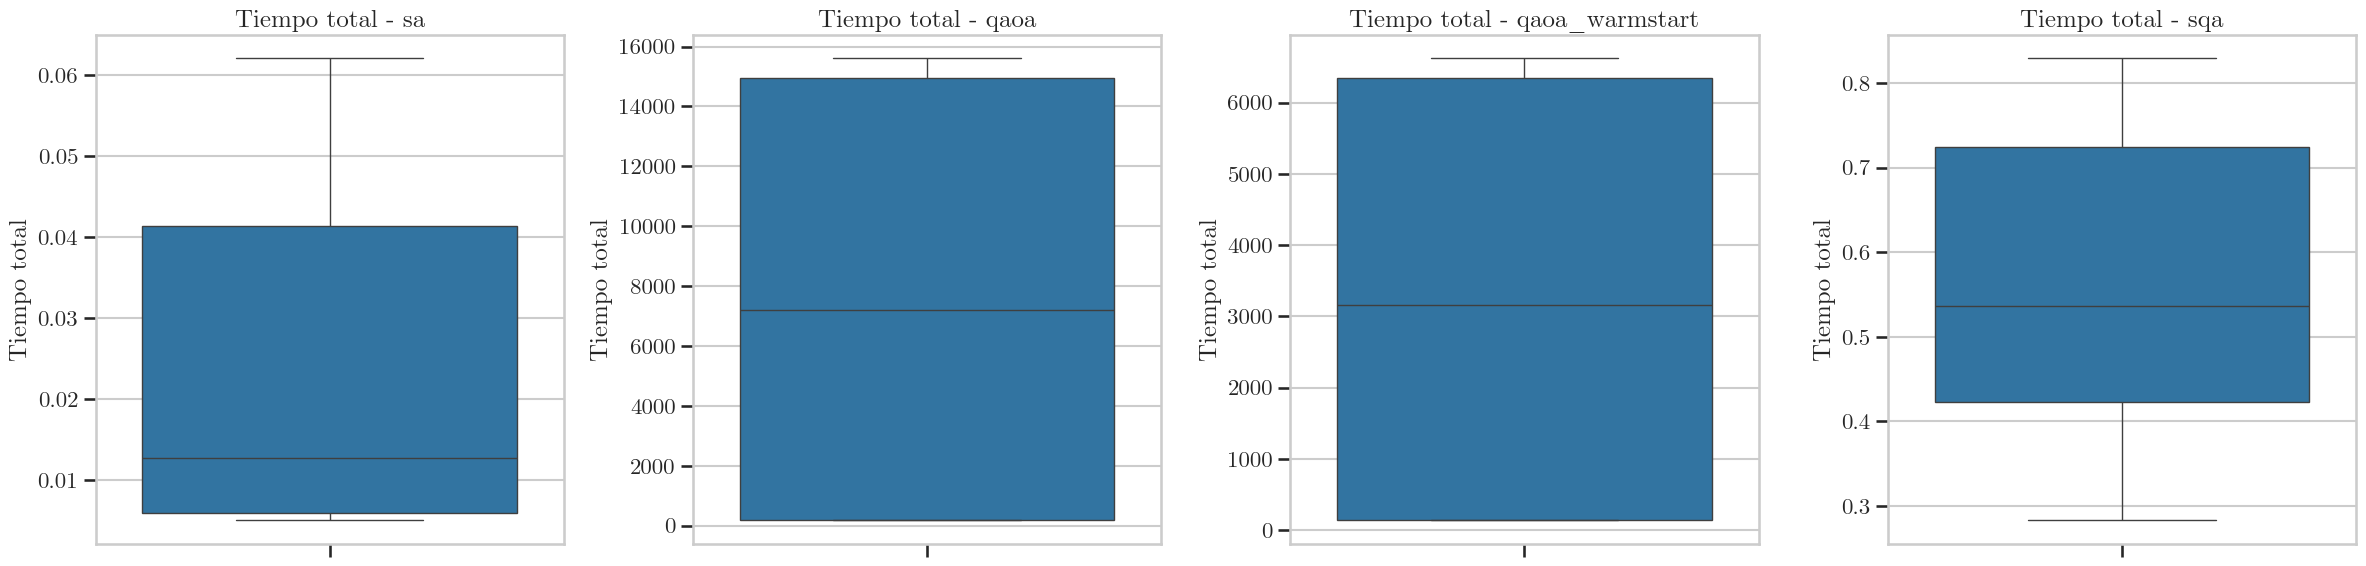

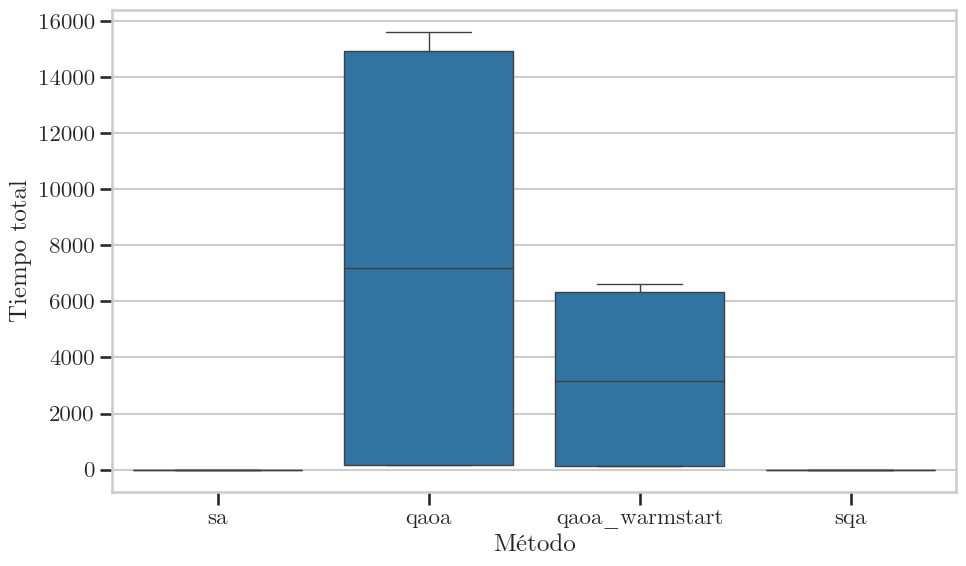

In [5]:
import os

#Crear carpeta si no existe
os.makedirs("figuras", exist_ok=True)

metodos = df['metodo'].unique()

#Gráficas individuales
fig, axes = plt.subplots(1, len(metodos), figsize=(6 * len(metodos), 6))

if len(metodos) == 1:
    axes = [axes]

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df['metodo'] == metodo],
        y='tiempo_total',
        ax=axes[i],
        showfliers=True
    )
    axes[i].set_title(f'Tiempo total - {metodo}')
    axes[i].set_ylabel('Tiempo total')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_por_metodo_individual.png", dpi=300, bbox_inches="tight")
plt.show()


#Comparación agregada
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='metodo',
    y='tiempo_total',
    showfliers=True
)

plt.xlabel('Método')
plt.ylabel('Tiempo total')

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_comparacion_metodos.png", dpi=300, bbox_inches="tight")
plt.show()

#### Análisis de escalabilidad con el tamaño del problema

En esta sección se realiza un análisis del comportamiento de los tiempos de ejecución a medida que aumenta el tamaño del problema. Para ello, se representa la mediana del tiempo total en función del número de ítems y del número de variables de la formulación QUBO. Este análisis, debido a las limitaciones en el tamaño de las instancias estudiadas, solo puede emplearse para observar cómo aumenta el tiempo cuando pasamos de instancias $2 \times 2$ a $3 \times 3$.

metodo,sa,sqa,qaoa,qaoa_warmstart
tamano_matriz,,,,
2x2,0.0057,0.6325,185.1032,147.5794
3x3,0.0128,0.6221,"14,856.6114","6,363.3202"
4x4,0.0438,0.4310,NaN,NaN


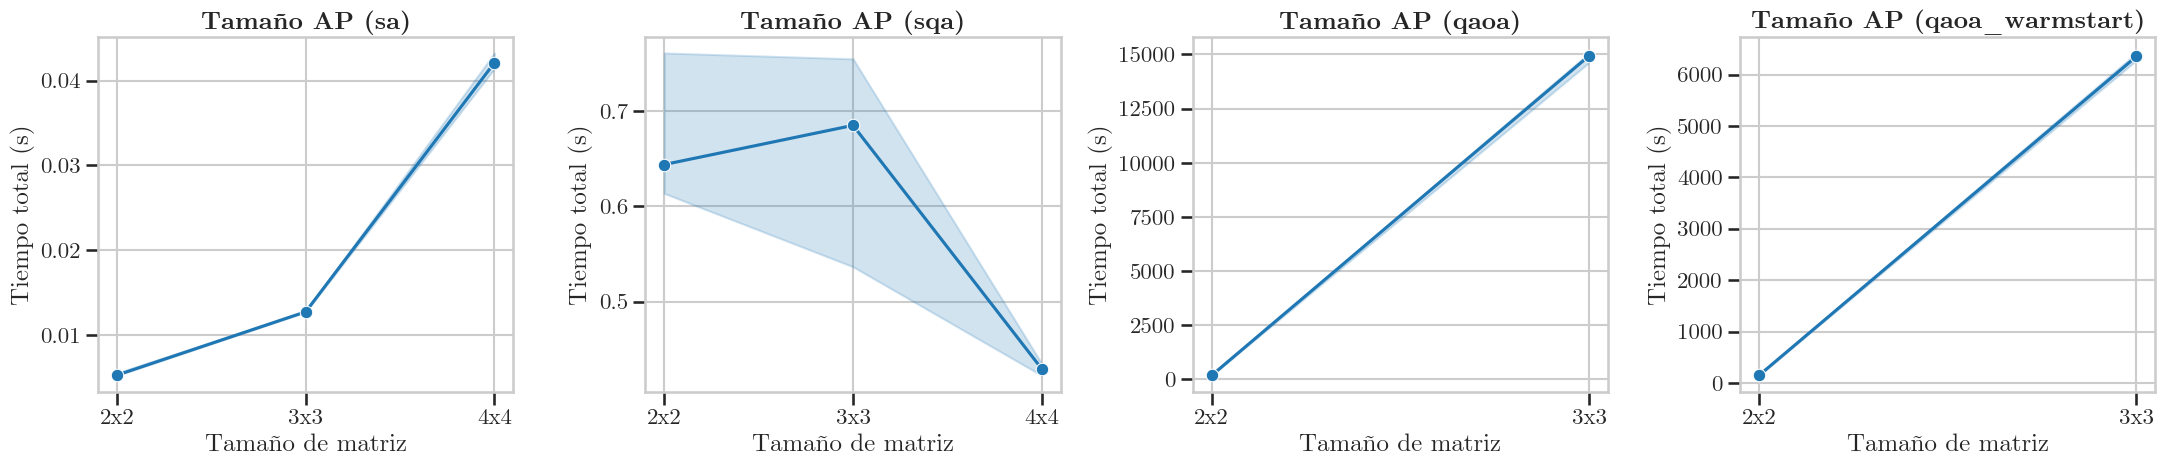

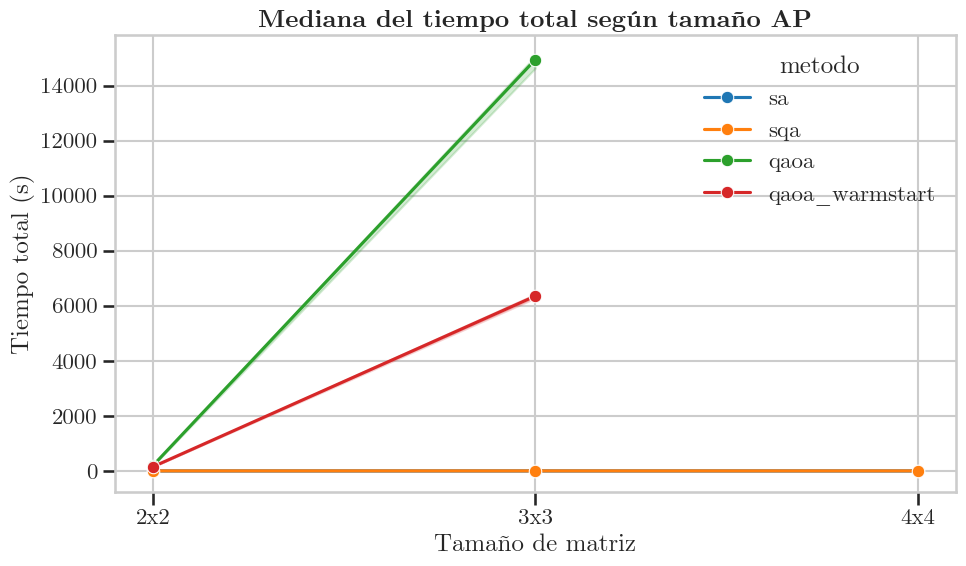

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = [
    "id",
    "optimo",
    "penalizacion",
    "coste_total",
    "violacion",
    "ratio_optimo",
    "tiempo_total"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

metodos = ["sa", "sqa", "qaoa", "qaoa_warmstart"]

#Tiempo medio por tamaño de matriz

tabla = (
    df
    .groupby(["tamano_matriz", "metodo"])["tiempo_total"]
    .mean()
    .unstack("metodo")
    .reindex(columns=metodos)
    .round(6)
)

display(tabla)

#Gráficos para cada método

fig, axes = plt.subplots(1, len(metodos), figsize=(22, 5), sharey=False)

for i, metodo in enumerate(metodos):
    df_metodo = df[df["metodo"] == metodo].copy()

    sns.lineplot(
        data=df_metodo,
        x="tamano_matriz",
        y="tiempo_total",
        estimator="median",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Tamaño AP ({metodo})", fontweight="bold")
    axes[i].set_xlabel("Tamaño de matriz")
    axes[i].set_ylabel("Tiempo total (s)")

plt.tight_layout()
plt.show()

#Gráfico agregado

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="tamano_matriz",
    y="tiempo_total",
    hue="metodo",
    hue_order=metodos,
    estimator="median",
    marker="o"
)

plt.title(
    "Mediana del tiempo total según tamaño AP",
    fontweight="bold"
)
plt.xlabel("Tamaño de matriz")
plt.ylabel("Tiempo total (s)")
plt.tight_layout()
plt.show()


## Contraste estadístico

In [11]:
import numpy as np
import pandas as pd
from scipy import stats

#Si todavia no lo has cargado:
#df = pd.read_csv("ap/resultados_ap.csv")

columnas_base = [
    "id",
    "tamano_matriz",
    "num_variables_qubo",
    "optimo",
    "penalizacion"
]

df["instancia_clave"] = df[columnas_base].astype(str).agg(" | ".join, axis=1)

columnas_numericas = [
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "ratio_medio_factibles",
    "tasa_factibilidad",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")


def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    std = diff.std(ddof=1)
    return diff.mean() / std if std != 0 else np.nan


def prueba_pareada(tabla, metodo_a, metodo_b, variable):
    x = tabla[metodo_a].dropna()
    y = tabla[metodo_b].dropna()

    datos = pd.concat([x, y], axis=1).dropna()
    x = datos[metodo_a]
    y = datos[metodo_b]
    diff = x - y

    shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan

    if pd.notna(shapiro_p) and shapiro_p > 0.05:
        test_name = "t-test apareado"
        pvalue = stats.ttest_rel(x, y).pvalue
    else:
        test_name = "Wilcoxon"
        try:
            pvalue = stats.wilcoxon(x, y).pvalue
        except ValueError:
            pvalue = np.nan

    return {
        "variable": variable,
        "metodo_a": metodo_a,
        "metodo_b": metodo_b,
        "comparacion": f"{metodo_a} vs {metodo_b}",
        "n_pares": len(datos),
        "mediana_metodo_a": np.median(x),
        "mediana_metodo_b": np.median(y),
        "media_metodo_a": np.mean(x),
        "media_metodo_b": np.mean(y),
        "shapiro_p_diferencias": shapiro_p,
        "prueba": test_name,
        "p_valor": pvalue,
        "cohens_d_paired": cohens_d_paired(x, y)
    }


comparables = df[df["metodo"].isin(["qaoa", "qaoa_warmstart", "sqa"])].copy()

agg = comparables.groupby(["instancia_clave", "metodo"], as_index=False).agg({
    "tiempo_total": "median",
    "prob_optimo_starts": "median",
    "prob_optimo_muestras": "median",
    "ratio_medio_factibles": "median",
    "tasa_factibilidad": "median",
})

resultados = []

comparaciones = [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]

metricas_comparables = [
    "tiempo_total",
    "prob_optimo_starts",
]

for variable in metricas_comparables:
    pivot = agg.pivot(
        index="instancia_clave",
        columns="metodo",
        values=variable
    )

    for metodo_a, metodo_b in comparaciones:
        tabla = pivot[[metodo_a, metodo_b]].dropna()

        if len(tabla) >= 2:
            resultados.append(
                prueba_pareada(
                    tabla=tabla,
                    metodo_a=metodo_a,
                    metodo_b=metodo_b,
                    variable=variable
                )
            )

tabla_resultados = pd.DataFrame(resultados)

display(tabla_resultados)

,variable,metodo_a,metodo_b,comparacion,n_pares,mediana_metodo_a,mediana_metodo_b,media_metodo_a,media_metodo_b,shapiro_p_diferencias,prueba,p_valor,cohens_d_paired
0,tiempo_total,qaoa,qaoa_warmstart,qaoa vs qaoa_warmstart,8,"7,337.9791","3,208.4842","7,511.7884","3,241.6909",0.0022,Wilcoxon,0.0078,0.9423
1,tiempo_total,qaoa,sqa,qaoa vs sqa,8,"7,337.9791",0.6666,"7,511.7884",0.6717,0.0015,Wilcoxon,0.0078,0.9585
2,tiempo_total,qaoa_warmstart,sqa,qaoa_warmstart vs sqa,8,"3,208.4842",0.6666,"3,241.6909",0.6717,0.0011,Wilcoxon,0.0078,0.9796
3,prob_optimo_starts,qaoa,qaoa_warmstart,qaoa vs qaoa_warmstart,8,0.6500,0.9000,0.6875,0.8500,0.0371,Wilcoxon,0.0625,-0.9192
4,prob_optimo_starts,qaoa,sqa,qaoa vs sqa,8,0.6500,0.9500,0.6875,0.9000,0.0526,t-test apareado,0.0310,-0.9520
5,prob_optimo_starts,qaoa_warmstart,sqa,qaoa_warmstart vs sqa,8,0.9000,0.9500,0.8500,0.9000,0.4158,t-test apareado,0.3807,-0.3307


## Correlaciones entre complejidad y coste computacional

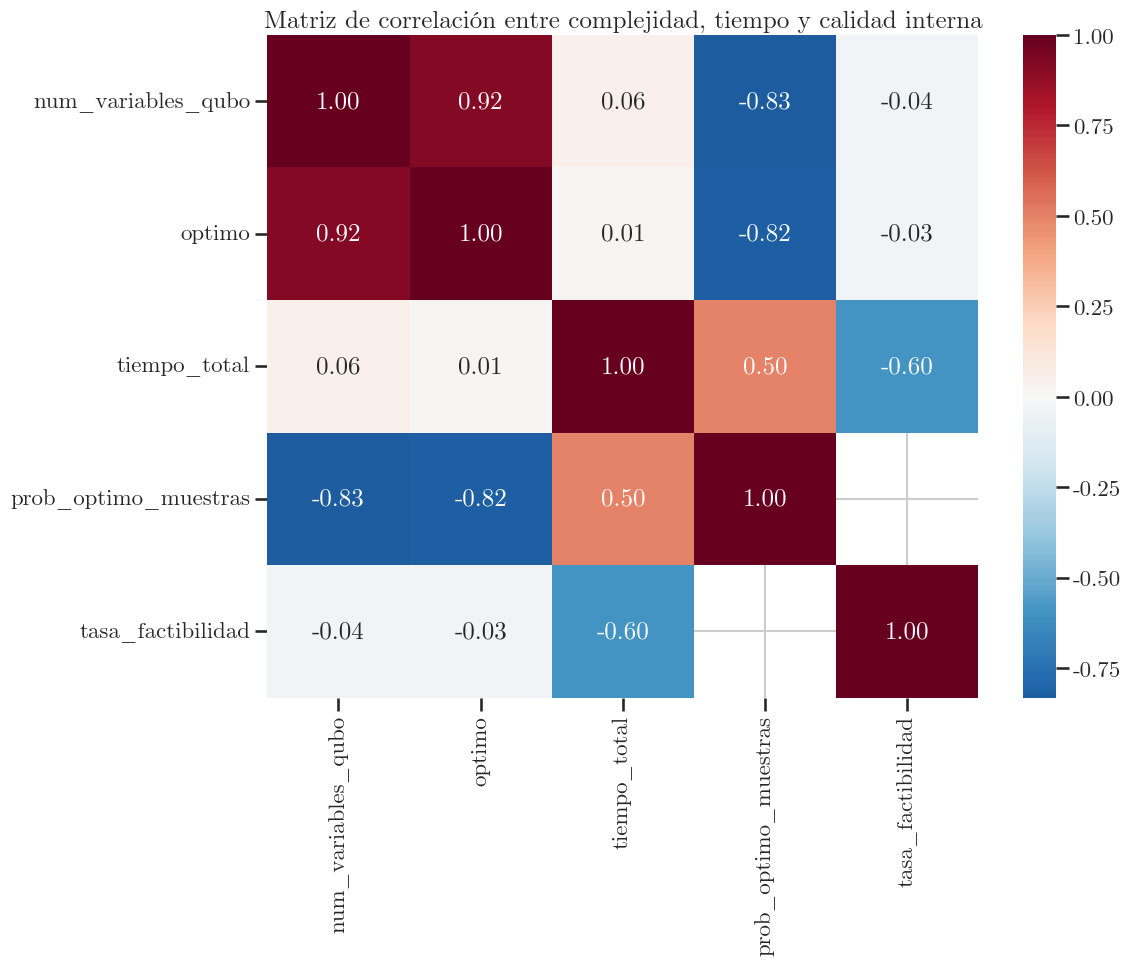

In [10]:
# Correlaciones entre complejidad y coste computacional
cols_corr = [
    'num_items', 'capacidad', 'num_variables_qubo', 'optimo',
    'tiempo_total', 't_solver',
    'prob_optimo', 'ratio_optimo_medio', 'prob_optimo_muestras',
    'tasa_factibilidad', 'valor_medio_start'
]
cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matriz de correlación entre complejidad, tiempo y calidad interna')
plt.tight_layout()
plt.savefig("figuras/matriz_correlacion_complejidad_tiempo_calidad_ap.png", dpi=300, bbox_inches="tight")
plt.show()

## Cálculo tiempo total de ejecución

In [12]:
df["tiempo_total"] = pd.to_numeric(df["tiempo_total"], errors="coerce")

tiempos_por_metodo = (
    df.groupby("metodo", as_index=False)
    .agg(
        num_ejecuciones=("tiempo_total", "count"),
        tiempo_total_segundos=("tiempo_total", "sum"),
    )
    .sort_values("tiempo_total_segundos", ascending=False)
)

tiempo_total_global = df["tiempo_total"].sum()

display(tiempos_por_metodo)

print(f"Tiempo total global: {tiempo_total_global:.4f} segundos")

,metodo,num_ejecuciones,tiempo_total_segundos
0,qaoa,40,"300,834.2917"
1,qaoa_warmstart,40,"130,217.9926"
3,sqa,60,33.7124
2,sa,60,1.2456


Tiempo total global: 431087.2424 segundos
Tiempo total global: 7184.7874 minutos
Tiempo total global: 119.7465 horas
